In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


df = pd.read_csv('../datasets/insurance - insurance.csv')


In [2]:
df.sample(10)

,age,sex,bmi,children,smoker,region,charges
886,57,male,28.975,0,yes,northeast,27218.43725
802,21,male,22.300,1,no,southwest,2103.08000
382,55,male,33.000,0,no,southeast,20781.48892
669,40,female,29.810,1,no,southeast,6500.23590
691,47,male,36.200,1,no,southwest,8068.18500
551,32,female,28.930,0,no,southeast,3972.92470
608,28,male,26.980,2,no,northeast,4435.09420
1242,22,female,21.280,3,no,northwest,4296.27120
209,40,male,41.230,1,no,northeast,6610.10970
49,36,male,35.200,1,yes,southeast,38709.17600


In [3]:
df.drop(columns = 'region', inplace= True)


In [4]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.drop_duplicates(inplace=True)


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
cat = ['sex', 'smoker']

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(df[cat])

encoded


array([[1., 0., 0., 1.],
       [0., 1., 1., 0.],
       [0., 1., 1., 0.],
       ...,
       [1., 0., 1., 0.],
       [1., 0., 1., 0.],
       [1., 0., 0., 1.]], shape=(1337, 4))

In [10]:
encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cat))
encoded_df

,sex_female,sex_male,smoker_no,smoker_yes
0,1.0,0.0,0.0,1.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,1.0,0.0
...,...,...,...,...
1332,0.0,1.0,1.0,0.0
1333,1.0,0.0,1.0,0.0
1334,1.0,0.0,1.0,0.0
1335,1.0,0.0,1.0,0.0


In [11]:
df = pd.concat([df, encoded_df], axis=1)

In [12]:
df.sample(5)

,age,sex,bmi,children,smoker,charges,sex_female,sex_male,smoker_no,smoker_yes
922,38.0,male,31.000,1.0,no,5488.26200,0.0,1.0,1.0,0.0
505,37.0,male,30.875,3.0,no,6796.86325,0.0,1.0,1.0,0.0
433,60.0,female,30.500,0.0,no,12638.19500,1.0,0.0,1.0,0.0
1223,20.0,female,24.420,0.0,yes,26125.67477,0.0,1.0,1.0,0.0
1023,18.0,male,23.320,1.0,no,1711.02680,1.0,0.0,1.0,0.0


In [13]:
df.drop(cat, axis=1, inplace= True)

In [14]:
df

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19.0,27.900,0.0,16884.92400,1.0,0.0,0.0,1.0
1,18.0,33.770,1.0,1725.55230,0.0,1.0,1.0,0.0
2,28.0,33.000,3.0,4449.46200,0.0,1.0,1.0,0.0
3,33.0,22.705,0.0,21984.47061,0.0,1.0,1.0,0.0
4,32.0,28.880,0.0,3866.85520,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...
1334,18.0,31.920,0.0,2205.98080,1.0,0.0,1.0,0.0
1335,18.0,36.850,0.0,1629.83350,1.0,0.0,1.0,0.0
1336,21.0,25.800,0.0,2007.94500,1.0,0.0,0.0,1.0
1337,61.0,29.070,0.0,29141.36030,NaN,NaN,NaN,NaN


In [15]:
df['charges'] = np.log1p(df['charges'])

## splitting dataset

In [16]:
df = df.dropna()

In [17]:
X = df.drop(columns= 'charges')
y = df['charges']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

np.float64(-0.08839278466392801)

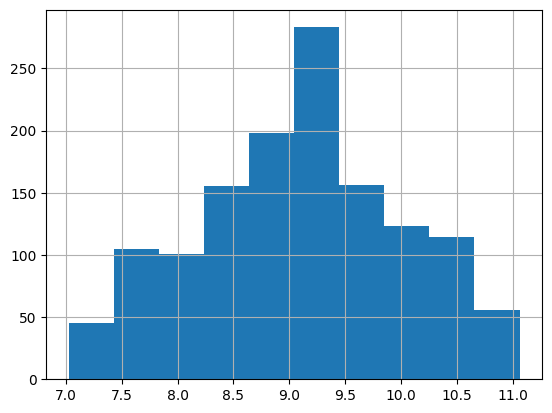

In [19]:
df['charges'].hist()
df['charges'].skew()

<Axes: >

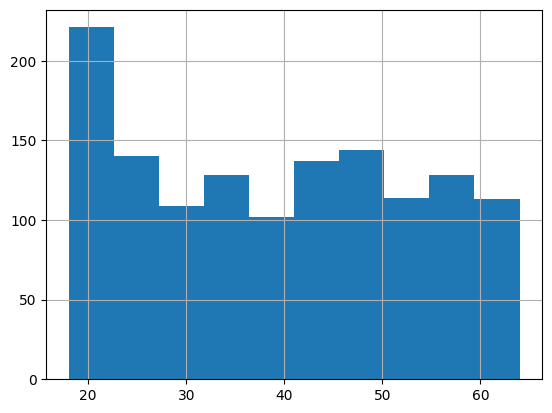

In [20]:
df['age'].hist()


<Axes: >

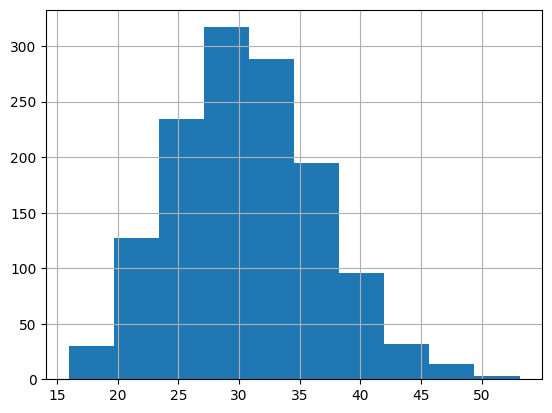

In [21]:
df['bmi'].hist()

In [22]:
num_cols = ['age', 'bmi','children']

scaler = StandardScaler()

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

In [23]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = lr.predict(X_test)

In [25]:
from sklearn.metrics import r2_score

accuracy = r2_score(y_test,y_pred)
accuracy

0.300333731325519

## Regularization


## Ridge

In [26]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridgeRegressor = Ridge()

In [27]:
parameter = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridgeRegressor, param_grid=parameter,scoring='neg_mean_squared_error', cv=5)
ridgecv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

In [28]:
print(ridgecv.best_params_)
print(ridgecv.best_score_)

{'alpha': 5}
-0.5104864363975115


In [29]:
ridge_pred = ridgecv.predict(X_test)

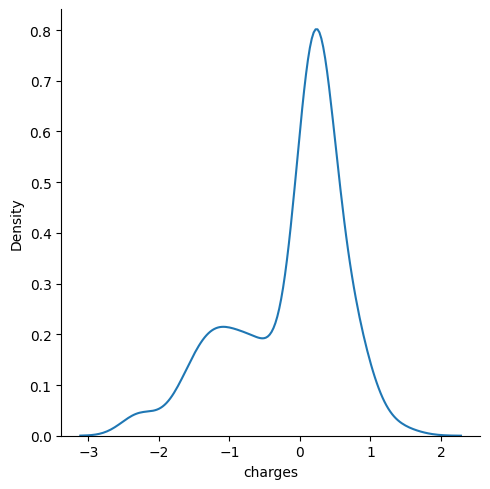

In [31]:
sns.displot(ridge_pred-y_test, kind = 'kde')

In [44]:
score = r2_score(ridge_pred,y_test)
score

-0.8962295118907257

## Lasso

In [35]:
from sklearn.linear_model import Lasso
lasso = Lasso()

In [37]:
parameter = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90],'max_iter': [100,200,500,1000,2000]}
lassocv = GridSearchCV(lasso, param_grid=parameter,scoring='neg_mean_squared_error', cv=5)
lassocv.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [1, 2, ...], 'max_iter': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fol

In [39]:
lasso_pred = lassocv.predict(X_test)

In [43]:
score1 = r2_score(lasso_pred,y_test)
score1

-2.840331204473893e+29